In [ ]:
import torch
import torchvision
import json
import os
from tqdm import tqdm
from PIL import Image
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
from torchvision.transforms import functional as F
from ultralytics import YOLO

VAL_IMG_DIR = "../data/valid/images"
VAL_ANN_FILE = "../data/annotations_val.json"
DATA_YAML = "../data/data.yaml"
CONF_THRESH = 0.5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

results = {}

def coco_eval(preds, coco_gt):
    output_json = "../results/temp_eval.json"
    with open(output_json, 'w') as f:
        json.dump(preds, f)
    coco_dt = coco_gt.loadRes(output_json)
    coco_eval = COCOeval(coco_gt, coco_dt, iouType='bbox')
    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()
    import numpy as np
    prec_vals = coco_eval.eval['precision'][0, :, 0, 0, 2]
    valid_prec = prec_vals[prec_vals >= 0]
    precision = float(np.mean(valid_prec)) if len(valid_prec) > 0 else 0.0
    recall = float(coco_eval.stats[8])
    return {
        "mAP@0.5": float(coco_eval.stats[1]),
        "Precision": precision,
        "Recall": recall,
        "F1": 2 * (precision * recall) / (precision + recall + 1e-6),
        "Inference_time": None
    }
    return {"mAP@0.5": ap50, "mAP@0.5:0.95": ap, "Precision": precision, "Recall": recall, "F1": f1}


def eval_yolo(model_path):
    model = YOLO(model_path)
    metrics = model.val(data=DATA_YAML, imgsz=640, device=DEVICE.index if DEVICE.type == "cuda" else "cpu")
    return {
        "mAP@0.5": metrics.box.map50,
        "mAP@0.5:0.95": metrics.box.map,
        "Precision": metrics.box.p[0],
        "Recall": metrics.box.r[0],
        "F1": metrics.box.f1[0]
    }

def eval_ssd(model_path):
    from torchvision.models.detection import ssd300_vgg16
    model = ssd300_vgg16(weights="DEFAULT")
    in_channels = [512, 1024, 512, 256, 256, 256]
    num_anchors = [4, 6, 6, 6, 4, 4]
    model.head.classification_head = torchvision.models.detection.ssd.SSDClassificationHead(
        in_channels=in_channels, num_anchors=num_anchors, num_classes=2
    )
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    model.to(DEVICE).eval()

    coco = COCO(VAL_ANN_FILE)
    preds = []
    for img_info in tqdm(coco.loadImgs(coco.getImgIds()), desc="SSD Eval"):
        path = os.path.join(VAL_IMG_DIR, img_info['file_name'])
        img = Image.open(path).convert("RGB")
        tensor = F.to_tensor(img).unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            output = model(tensor)[0]

        for box, score, label in zip(output['boxes'], output['scores'], output['labels']):
            if score < CONF_THRESH:
                continue
            x1, y1, x2, y2 = box.cpu().numpy()
            preds.append({
                "image_id": img_info['id'],
                "category_id": int(label),
                "bbox": [float(x1), float(y1), float(x2 - x1), float(y2 - y1)],
                "score": float(score)
            })

    return coco_eval(preds, coco)

def eval_frcnn(model_path):
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(in_features, 2)
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    model.to(DEVICE).eval()

    coco = COCO(VAL_ANN_FILE)
    preds = []
    for img_info in tqdm(coco.loadImgs(coco.getImgIds()), desc="Faster R-CNN Eval"):
        path = os.path.join(VAL_IMG_DIR, img_info['file_name'])
        img = Image.open(path).convert("RGB")
        tensor = F.to_tensor(img).unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            output = model(tensor)[0]

        for box, score, label in zip(output['boxes'], output['scores'], output['labels']):
            if score < CONF_THRESH:
                continue
            x1, y1, x2, y2 = box.cpu().numpy()
            preds.append({
                "image_id": img_info['id'],
                "category_id": int(label),
                "bbox": [float(x1), float(y1), float(x2 - x1), float(y2 - y1)],
                "score": float(score)
            })

    return coco_eval(preds, coco)

print("\n Evaluating YOLO...")
results["YOLO"] = eval_yolo("../models/yolov11/tuned.pt")

print("\n Evaluating SSD...")
results["SSD"] = eval_ssd("../models/ssd/ssd_speedbump_tuned.pth")

print("\n Evaluating Faster R-CNN...")
results["Faster R-CNN"] = eval_frcnn("../models/faster_rcnn/fasterrcnn_speedbump_tuned.pth")

print("\n Model Comparison:")
header = ["Model", "mAP@0.5", "mAP@0.5:0.95", "Precision", "Recall", "F1 Score", "Accuracy"]
print("{:<15} {:<10} {:<14} {:<10} {:<10} {:<10} {:<10}".format(*header))
for model, metrics in results.items():
    precision = metrics["Precision"]
    recall = metrics["Recall"]
    f1 = metrics["F1"]
    accuracy = (precision + recall) / 2
    print("{:<15} {:<10.4f} {:<14.4f} {:<10.4f} {:<10.4f} {:<10.4f} {:<10.4f}".format(
        model,
        metrics["mAP@0.5"],
        metrics["mAP@0.5:0.95"],
        precision,
        recall,
        f1,
        accuracy
    ))



 Evaluating YOLO...
Ultralytics 8.3.159  Python-3.12.4 torch-2.7.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Ti, 16310MiB)
YOLO11n summary (fused): 100 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access  (ping: 0.10.1 ms, read: 94.786.4 MB/s, size: 51.1 KB)


val: Scanning C:\Users\faizj\OneDrive\Desktop\others\SIKE\FYP\Model\Model Yolov11\valid\labels.cache... 1672 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1672/1672 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 105/105 [00:10<00:00,  9.81it/s]


                   all       1672       1872      0.964      0.964      0.976      0.757
Speed: 0.2ms preprocess, 2.2ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to runs\detect\val11

 Evaluating SSD...
loading annotations into memory...
Done (t=0.02s)
creating index...
index created!


SSD Eval: 100%|██████████| 1672/1672 [00:35<00:00, 47.08it/s]


Loading and preparing results...
DONE (t=0.01s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.27s).
Accumulating evaluation results...
DONE (t=0.05s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.515
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.743
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.589
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.272
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.571
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.541
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.571
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.571
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=10

Faster R-CNN Eval: 100%|██████████| 1672/1672 [01:22<00:00, 20.29it/s]


Loading and preparing results...
DONE (t=0.02s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.29s).
Accumulating evaluation results...
DONE (t=0.06s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.489
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.882
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.496
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.064
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.319
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.525
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.539
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.567
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.567
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=10

loading annotations into memory...
Done (t=0.04s)
creating index...
index created!
Classes: ['speed_bump']
Total Images: 6983
Total Annotations: 7854


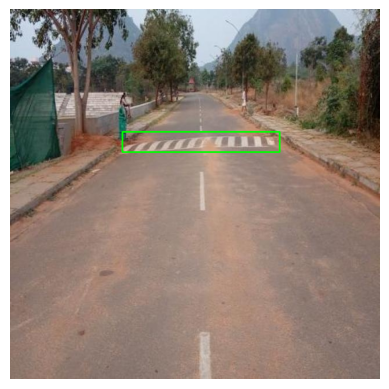

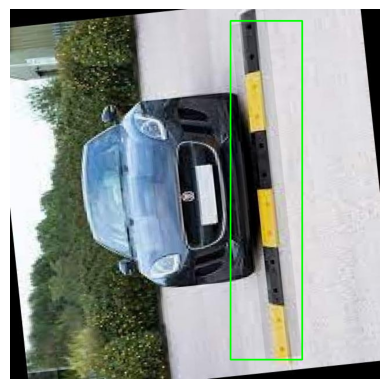

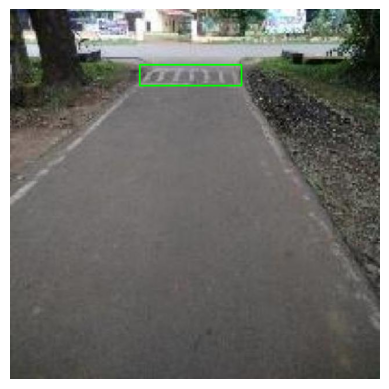

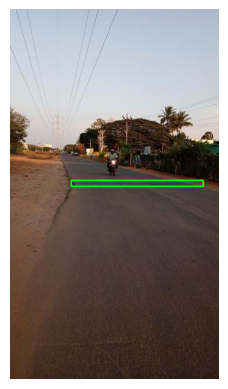

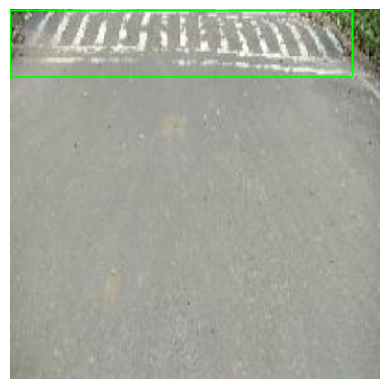

In [1]:
from pycocotools.coco import COCO
import matplotlib.pyplot as plt
import os
import cv2
import random

# Load COCO annotations
annFile = '../data/annotations_train.json'
coco = COCO(annFile)

# Class summary
categories = coco.loadCats(coco.getCatIds())
print("Classes:", [cat['name'] for cat in categories])

# Number of images
image_ids = coco.getImgIds()
print(f"Total Images: {len(image_ids)}")

# Number of annotations
ann_ids = coco.getAnnIds()
print(f"Total Annotations: {len(ann_ids)}")

# Visualize random images with boxes
for _ in range(5):
    img_id = random.choice(image_ids)
    img_info = coco.loadImgs(img_id)[0]
    img_path = os.path.join("../data/train/images", img_info['file_name'])
    image = cv2.imread(img_path)

    ann_ids = coco.getAnnIds(imgIds=img_id)
    anns = coco.loadAnns(ann_ids)

    for ann in anns:
        x, y, w, h = map(int, ann['bbox'])
        cv2.rectangle(image, (x, y), (x + w, y + h), (0, 255, 0), 2)

    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()


In [1]:
import os
import pandas as pd

# Count images and labels
image_files = os.listdir('../data/valid/images')
label_files = os.listdir('../data/valid/labels')
print(f"Total Images: {len(image_files)}, Labels: {len(label_files)}")

Total Images: 1672, Labels: 1672
